## Experiment No: 3
## Experiment Title: Multiple Linear Regression using a real-world open-access dataset, evaluated using MSE, RMSE, and R²

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Required Libraries

In [1]:
# Importing libraries needed for data handling, modeling, and evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# For nicer looking plots
sns.set(style="whitegrid")


### Step 2: Load the Dataset

In [2]:
# Using the Diabetes dataset (real-world, open-access, built into sklearn)
# It contains 10 baseline health features and the target is disease progression after 1 year
diabetes = load_diabetes(as_frame=True)

# Converting to a pandas DataFrame for easy handling
df = diabetes.frame

# Displaying first 5 rows to understand the structure
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Step 3: Explore the Dataset

In [3]:
# Checking basic info like data types and null values
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
# Checking statistical summary of the dataset
df.describe()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
# Checking for missing values in each column
print("Missing values in each column:\n")
print(df.isnull().sum())


Missing values in each column:

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


### Step 4: Feature Selection (Independent and Dependent Variables)

In [6]:
# 'target' is the dependent variable (disease progression score after 1 year)
# All other columns are used as independent features for multiple linear regression
X = df.drop("target", axis=1)
y = df["target"]

print("Independent Variables (Features):")
print(X.columns.tolist())
print("\nDependent Variable (Target): target (disease progression)")


Independent Variables (Features):
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Dependent Variable (Target): target (disease progression)


### Step 5: Visualize Correlation Between Features

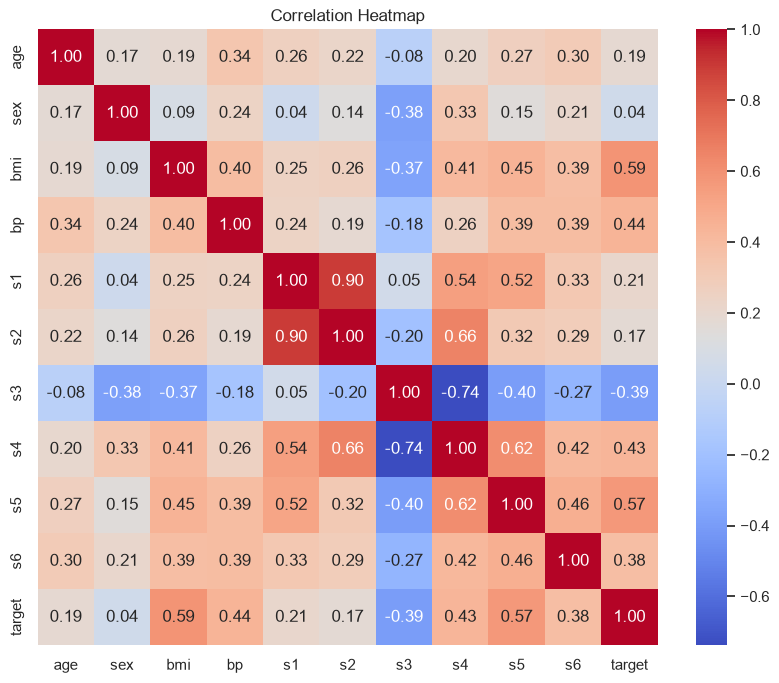

In [7]:
# Plotting a heatmap to see how features are correlated with each other and target
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### Step 6: Split Data into Training and Testing Sets

In [8]:
# Splitting data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (353, 10)
Testing set size: (89, 10)


### Step 7: Build and Train the Multiple Linear Regression Model

In [9]:
# Creating the Linear Regression model
model = LinearRegression()

# Training the model using the training data
model.fit(X_train, y_train)

# Displaying the learned coefficients for each feature
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print("Intercept:", model.intercept_)
print("\nCoefficients:\n")
print(coeff_df)


Intercept: 151.34560453985995

Coefficients:

     Coefficient
age    37.904021
sex  -241.964362
bmi   542.428759
bp    347.703844
s1   -931.488846
s2    518.062277
s3    163.419983
s4    275.317902
s5    736.198859
s6     48.670657


### Step 8: Make Predictions on Test Data

In [10]:
# Predicting disease progression scores for the test set
y_pred = model.predict(X_test)

# Comparing actual vs predicted values for first 10 samples
comparison_df = pd.DataFrame({"Actual": y_test.values[:10], "Predicted": y_pred[:10]})
print(comparison_df)


   Actual   Predicted
0   219.0  139.547558
1    70.0  179.517208
2   202.0  134.038756
3   230.0  291.417029
4   111.0  123.789659
5    84.0   92.172347
6   242.0  258.232389
7   272.0  181.337321
8    94.0   90.224113
9    96.0  108.633759


### Step 9: Evaluate the Model using MSE, RMSE, and R²

In [11]:
# Mean Squared Error - average of squared differences between actual and predicted
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error - square root of MSE, same unit as target variable
rmse = np.sqrt(mse)

# R-squared - how well the model explains the variance in the target variable
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-------------------------")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score)      : {r2:.4f}")


Model Evaluation Metrics
-------------------------
Mean Squared Error (MSE)  : 2900.1936
Root Mean Squared Error (RMSE): 53.8534
R-squared (R2 Score)      : 0.4526


### Step 10: Visualize Actual vs Predicted Values

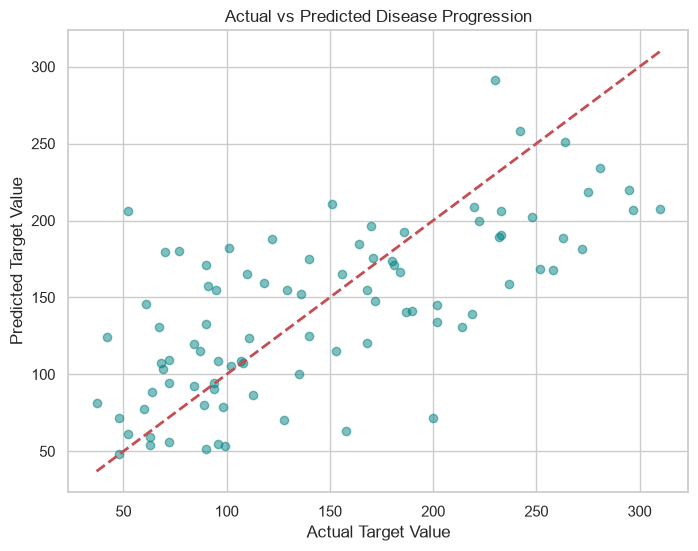

In [12]:
# Scatter plot to visually compare actual vs predicted disease progression scores
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Target Value")
plt.ylabel("Predicted Target Value")
plt.title("Actual vs Predicted Disease Progression")
plt.show()


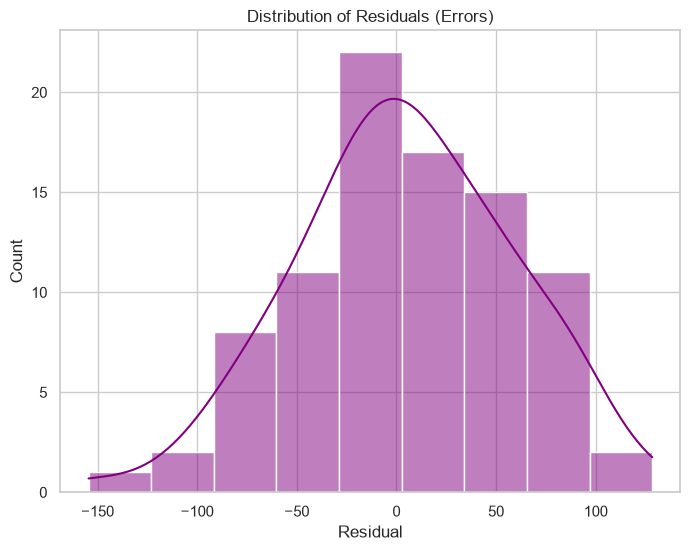

In [13]:
# Plotting residuals (errors) to check the distribution of prediction errors
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color="purple")
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residual")
plt.show()


### Step 11: Final Output

In [14]:
print("Experiment Completed Successfully")
print("\nFinal Model Performance Summary:")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")


Experiment Completed Successfully

Final Model Performance Summary:
MSE  = 2900.1936
RMSE = 53.8534
R2   = 0.4526
